# 📊 Evaluación Extendida del Modelo Predictivo
## Sistema de Predicción de Ocupación Hotelera en Canarias
### Sección 8 — Informe de Rendimiento y Métricas

---

Este notebook reproduce el **pipeline completo de entrenamiento y evaluación** del modelo XGBoost desarrollado para predecir la tasa de ocupación hotelera en Canarias, añadiendo métricas adicionales de diagnóstico que complementan las del script principal `src/train_models.py`.

**Compatible con:** Google Colab · IsardVDI · Jupyter Lab · VS Code Notebooks

---

## 0. Instalación de Dependencias

In [1]:
# Ejecutar solo si estás en Google Colab o IsardVDI
import subprocess, sys

packages = ['xgboost', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Dependencias instaladas correctamente.')

✅ Dependencias instaladas correctamente.


## 1. Imports y Configuración Global

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)
from sklearn.preprocessing import KBinsDiscretizer
from scipy import stats
from xgboost import XGBRegressor

# ─── Estilo global de gráficos ───────────────────────────────────────────────
DARK_BG   = '#0f172a'
CARD_BG   = '#1e293b'
ACCENT    = '#38bdf8'
ORANGE    = '#fb923c'
GREEN     = '#34d399'
PURPLE    = '#a78bfa'
RED       = '#f43f5e'
YELLOW    = '#fbbf24'
TEXT      = '#f8fafc'
MUTED     = '#94a3b8'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor': CARD_BG,
    'axes.edgecolor': '#334155',
    'text.color': TEXT,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'grid.color': '#334155',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'figure.dpi': 130
})

print('✅ Configuración de entorno lista.')

✅ Configuración de entorno lista.


## 1b. Limpieza de Datos Crudos → Archivos `_limpio.csv`

> Ejecuta esta sección **solo si** tus archivos en `data/raw/` son los CSV originales sin procesar.  
> Genera los archivos `*_limpio.csv` en `data/processed/` que necesitan el resto del notebook.  
> Si ya tienes los `_limpio.csv`, puedes **saltarte** esta sección.

In [5]:
import os, re
import pandas as pd
import numpy as np

# ─── Detección automática de rutas ───────────────────────────────────────────
CANDIDATES_RAW = [
    '/content/raw',                                               # Nueva ruta detectada
    '/content/data/raw',                                          # Colab (estructura estándar)
    '/content/drive/MyDrive/Proyecto de clase/data/raw',         # Colab + Google Drive
    '/content',                                                   # Colab (archivos subidos raíz)
    '../data/raw',                                                # Local / IsardVDI
    'data/raw',
]
CANDIDATES_PROC = [
    '/content/data/processed',                                    # Colab (estructura estándar)
    '/content/drive/MyDrive/Proyecto de clase/data/processed',   # Colab + Google Drive
    '/content/processed',                                         # Colab alternativo
    '../data/processed',                                          # Local / IsardVDI
    'data/processed',
]

RAW_PATH = next((c for c in CANDIDATES_RAW if os.path.isdir(c)), '/content/data/raw')
PROC_PATH = next((c for c in CANDIDATES_PROC if os.path.isdir(c)), '/content/data/processed')
os.makedirs(PROC_PATH, exist_ok=True)

print(f'📂 Raw      : {RAW_PATH}')
print(f'📂 Processed: {PROC_PATH}')

# ─── Archivos a procesar (Nombres actualizados según el sistema de archivos) ──
RAW_FILES = {
    'hoteles'              : 'hoteles_categorias.csv',
    'apartamentos'         : 'apartamentos.csv',
    'estrellas_3'          : 'establecimientos_3_estrellas.csv',
    'viviendas_vacacionales': 'viviendas_vacacionales.csv',
}

# ─── Función de limpieza genérica para datos ISTAC de ocupación ───────────────
def limpiar_dataset(path, fuente):
    # Se elimina low_memory=False porque no es compatible con engine='python'
    df = pd.read_csv(path, sep=None, engine='python')

    # 1. Estandarizar nombres de columna
    df.columns = (
        df.columns
          .str.strip()
          .str.upper()
          .str.replace(' ', '_', regex=False)
          .str.replace(r'[^A-Z0-9_]', '', regex=True)
    )

    # 2. Detectar columna de fecha
    date_candidates = [c for c in df.columns if any(k in c for k in ['DATE','TIME','PERIOD','FECHA','AO','MES'])]
    if not date_candidates:
        raise ValueError(f'[{fuente}] No se detectó columna de fecha. Columnas: {df.columns.tolist()}')
    date_col = date_candidates[0]

    def parse_date(s):
        s = str(s).strip()
        for fmt in ('%Y-%m', '%Y/%m', '%m/%Y', '%Y-%m-%d', '%d/%m/%Y'):
            try:
                return pd.to_datetime(s, format=fmt)
            except:
                pass
        return pd.NaT

    df['Date'] = df[date_col].apply(parse_date)
    df = df.dropna(subset=['Date'])
    df['Year']  = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

    # 3. Columna de valor observado
    obs_candidates = [c for c in df.columns if 'OBS' in c or 'VALUE' in c or 'VALOR' in c]
    if not obs_candidates:
        raise ValueError(f'[{fuente}] No se detectó columna de valor. Columnas: {df.columns.tolist()}')
    obs_col = obs_candidates[0]
    if obs_col != 'OBS_VALUE':
        df = df.rename(columns={obs_col: 'OBS_VALUE'})

    df['OBS_VALUE'] = (
        df['OBS_VALUE']
          .astype(str)
          .str.replace(',', '.', regex=False)
          .str.strip()
          .replace({'-': np.nan, '': np.nan, 'nan': np.nan, 'NaN': np.nan})
    )
    df['OBS_VALUE'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce')

    # 4. Eliminar duplicados
    before = len(df)
    df = df.drop_duplicates()
    print(f'  [{fuente}] Duplicados eliminados: {before - len(df)}')

    # 5. Descartar sin OBS_VALUE
    df = df.dropna(subset=['OBS_VALUE'])

    # 6. Indicador de pandemia
    df['is_pandemic'] = df['Year'].isin([2020, 2021]).astype(int)

    # 7. Recortar valores fuera de [0, 100]
    outliers = (df['OBS_VALUE'] < 0) | (df['OBS_VALUE'] > 100)
    if outliers.sum() > 0:
        print(f'  [{fuente}] Valores fuera de [0,100] → NaN: {outliers.sum()}')
        df.loc[outliers, 'OBS_VALUE'] = np.nan
        df = df.dropna(subset=['OBS_VALUE'])

    # Asegurar columnas clave
    for col, default in [
        ('TERRITORIO_CODE', 'ES70'),
        ('MEDIDAS_CODE',    'TASA_OCUPACION_HABITACION'),
        ('ALOJAMIENTO_TURISTICO_CATEGORIA_CODE', '_T'),
    ]:
        if col not in df.columns:
            df[col] = default
            print(f'  [{fuente}] Columna {col} no encontrada → valor por defecto "{default}"')

    return df.reset_index(drop=True)

# ─── Procesar y guardar ───────────────────────────────────────────────────────
print('\nProcesando datasets...\n')
for fuente, filename in RAW_FILES.items():
    raw_path = os.path.join(RAW_PATH, filename)
    out_path = os.path.join(PROC_PATH, f'{fuente}_limpio.csv')

    if not os.path.exists(raw_path):
        print(f'⚠️  [{fuente}] No encontrado: {raw_path}')
        continue
    try:
        df_clean = limpiar_dataset(raw_path, fuente)
        df_clean.to_csv(out_path, index=False)
        print(f'  ✅ [{fuente}] {len(df_clean):,} registros → {out_path}\n')
    except Exception as e:
        print(f'  ❌ [{fuente}] Error: {e}\n')

print('\n✅ Limpieza completada. Continúa con la sección 2.')

📂 Raw      : /content/raw
📂 Processed: /content/data/processed

Procesando datasets...

  [hoteles] Duplicados eliminados: 0
  [hoteles] Valores fuera de [0,100] → NaN: 51688
  ✅ [hoteles] 79,222 registros → /content/data/processed/hoteles_limpio.csv

  [apartamentos] Duplicados eliminados: 0
  [apartamentos] Valores fuera de [0,100] → NaN: 36058
  ✅ [apartamentos] 58,187 registros → /content/data/processed/apartamentos_limpio.csv

  [estrellas_3] Duplicados eliminados: 0
  [estrellas_3] Valores fuera de [0,100] → NaN: 115995
  [estrellas_3] Columna ALOJAMIENTO_TURISTICO_CATEGORIA_CODE no encontrada → valor por defecto "_T"
  ✅ [estrellas_3] 112,272 registros → /content/data/processed/estrellas_3_limpio.csv

  [viviendas_vacacionales] Duplicados eliminados: 0
  [viviendas_vacacionales] Valores fuera de [0,100] → NaN: 27492
  [viviendas_vacacionales] Columna ALOJAMIENTO_TURISTICO_CATEGORIA_CODE no encontrada → valor por defecto "_T"
  ✅ [viviendas_vacacionales] 23,142 registros → /conte

## 2. Carga y Preparación del Dataset

In [6]:
import os

# ─── Detección automática de rutas ───────────────────────────────────────────
CANDIDATES = [
    '/content/data/processed',                                          # Colab (estructura estándar)
    '/content/drive/MyDrive/Proyecto de clase/data/processed',         # Colab + Google Drive
    '/content/processed',                                               # Colab (carpeta directa)
    '/content',                                                         # Colab (archivos subidos raíz)
    '../data/processed',                                                # Local / IsardVDI relativo
    'data/processed',                                                   # Local / IsardVDI alternativo
]

FILENAMES = ['hoteles_limpio.csv', 'apartamentos_limpio.csv',
             'estrellas_3_limpio.csv', 'viviendas_vacacionales_limpio.csv']

BASE_PATH = None
for candidate in CANDIDATES:
    if any(os.path.exists(os.path.join(candidate, f)) for f in FILENAMES):
        BASE_PATH = candidate
        break

if BASE_PATH is None:
    print('⚠️  No se encontraron los archivos _limpio.csv en ninguna ruta conocida.')
    print('   Ajusta BASE_PATH manualmente:')
    BASE_PATH = '/content/data/processed'   # <── edita esto si es necesario

print(f'📂 BASE_PATH: {BASE_PATH}')

# ─── Datasets a combinar ─────────────────────────────────────────────────────
DATASETS = {
    'hoteles'              : 'hoteles_limpio.csv',
    'apartamentos'         : 'apartamentos_limpio.csv',
    'estrellas_3'          : 'estrellas_3_limpio.csv',
    'viviendas_vacacionales': 'viviendas_vacacionales_limpio.csv',
}

dfs = []
for fuente, filename in DATASETS.items():
    path = os.path.join(BASE_PATH, filename)
    if not os.path.exists(path):
        print(f'⚠️  No encontrado: {path}  — se omite')
        continue
    df_tmp = pd.read_csv(path, low_memory=False)
    df_tmp['fuente'] = fuente
    dfs.append(df_tmp)
    print(f'  ✅ {fuente:<25} {df_tmp.shape[0]:>6,} filas × {df_tmp.shape[1]-1} columnas')

if not dfs:
    raise FileNotFoundError(
        'No se encontró ningún dataset _limpio.csv.\n'
        '→ Ejecuta primero la sección 1b para limpiar los CSV crudos, '
        'o ajusta BASE_PATH a la carpeta correcta.'
    )

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\nDataset combinado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Fuentes cargadas : {df_raw["fuente"].unique().tolist()}')
df_raw.head(3)


📂 BASE_PATH: /content/data/processed
  ✅ hoteles                   79,222 filas × 18 columnas
  ✅ apartamentos              58,187 filas × 18 columnas
  ✅ estrellas_3               112,272 filas × 21 columnas
  ✅ viviendas_vacacionales    23,142 filas × 17 columnas

Dataset combinado: 272,823 filas × 25 columnas
Fuentes cargadas : ['hoteles', 'apartamentos', 'estrellas_3', 'viviendas_vacacionales']


,TIME_PERIODES,TIME_PERIOD_CODE,TERRITORIOES,TERRITORIO_CODE,MEDIDASES,MEDIDAS_CODE,ALOJAMIENTO_TURISTICO_CATEGORIAES,ALOJAMIENTO_TURISTICO_CATEGORIA_CODE,OBS_VALUE,NOTAS_OBSERVACIONES,...,Year,Month,is_pandemic,fuente,ALOJAMIENTO_TURISTICO_TIPOES,ALOJAMIENTO_TURISTICO_TIPO_CODE,NACIONALIDADES,NACIONALIDAD_CODE,INTERVALOS_PLAZASES,INTERVALOS_PLAZAS_CODE
0,06/2019,2019-M06,Canarias,ES70,Establecimientos,ESTABLECIMIENTOS,2 Estrellas,ESTRELLAS_2,66.0,NaN,...,2019,6,0,hoteles,NaN,NaN,NaN,NaN,NaN,NaN
1,07/2019,2019-M07,Canarias,ES70,Establecimientos,ESTABLECIMIENTOS,2 Estrellas,ESTRELLAS_2,65.0,NaN,...,2019,7,0,hoteles,NaN,NaN,NaN,NaN,NaN,NaN
2,08/2019,2019-M08,Canarias,ES70,Establecimientos,ESTABLECIMIENTOS,2 Estrellas,ESTRELLAS_2,66.0,NaN,...,2019,8,0,hoteles,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ─── Filtrar Canarias total + Tasa de Ocupación por Habitación ───────────────
df = df_raw[
    (df_raw['TERRITORIO_CODE'] == 'ES70') &
    (df_raw['MEDIDAS_CODE'] == 'TASA_OCUPACION_HABITACION')
].copy()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['fuente', 'ALOJAMIENTO_TURISTICO_CATEGORIA_CODE', 'Date']).reset_index(drop=True)
print(f'Registros filtrados (Canarias, habitación): {len(df):,}')
print(f'Por fuente:\n{df.groupby("fuente").size().to_string()}')

# ─── Feature Engineering ─────────────────────────────────────────────────────
# Se agrupa por (fuente + categoría) para calcular lags correctamente
# sin mezclar series temporales de distintos tipos de alojamiento
GROUP_COLS = ['fuente', 'ALOJAMIENTO_TURISTICO_CATEGORIA_CODE']
grouped = df.groupby(GROUP_COLS)

df['lag_1']          = grouped['OBS_VALUE'].shift(1)
df['lag_2']          = grouped['OBS_VALUE'].shift(2)
df['lag_12']         = grouped['OBS_VALUE'].shift(12)
df['rolling_mean_3'] = grouped['OBS_VALUE'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Month']          = df['Month'].astype(int)

# Codificar la fuente como variable numérica (opcional, mejora el modelo)
df['fuente_cod'] = pd.Categorical(df['fuente']).codes

df_ml = df.dropna(subset=['lag_1','lag_2','lag_12','rolling_mean_3','OBS_VALUE']).copy()

# ─── Split Temporal ───────────────────────────────────────────────────────────
FEATURES = ['Month','lag_1','lag_2','lag_12','rolling_mean_3','is_pandemic','fuente_cod']
TARGET   = 'OBS_VALUE'

train_df = df_ml[df_ml['Year'] <= 2024].copy()
test_df  = df_ml[df_ml['Year']  > 2024].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

print(f'\nTrain: {len(X_train):,} muestras  |  Test: {len(X_test):,} muestras')
print(f'Período train: {train_df["Date"].min().date()} → {train_df["Date"].max().date()}')
print(f'Período test : {test_df["Date"].min().date()}  → {test_df["Date"].max().date()}')
print(f'Features     : {FEATURES}')


Registros filtrados (Canarias, habitación): 2,883
Por fuente:
fuente
apartamentos    1236
hoteles         1647

Train: 2,505 muestras  |  Test: 210 muestras
Período train: 2010-01-01 → 2024-12-01
Período test : 2025-01-01  → 2026-03-01
Features     : ['Month', 'lag_1', 'lag_2', 'lag_12', 'rolling_mean_3', 'is_pandemic', 'fuente_cod']


## 3. Entrenamiento y Validación Cruzada Temporal

In [8]:
MODELS = {
    'Regresión Lineal' : LinearRegression(),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost'          : XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    'Red Neuronal (ANN)': MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42)
}

tscv = TimeSeriesSplit(n_splits=3)
cv_results = {}
test_preds = {}

print('Entrenando y evaluando modelos...\n')
for name, model in MODELS.items():
    # Validación cruzada temporal
    fold_rmse, fold_r2 = [], []
    for tr_idx, val_idx in tscv.split(X_train):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        p = model.predict(X_train.iloc[val_idx])
        fold_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], p)))
        fold_r2.append(r2_score(y_train.iloc[val_idx], p))

    # Evaluación final en test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_preds[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    cv_results[name] = {
        'CV_RMSE': np.mean(fold_rmse), 'CV_R2': np.mean(fold_r2),
        'Test_MAE': mae, 'Test_RMSE': rmse, 'Test_R2': r2, 'Test_MAPE': mape
    }
    print(f'[{name}]')
    print(f'  CV  → RMSE: {np.mean(fold_rmse):.3f} | R²: {np.mean(fold_r2):.3f}')
    print(f'  Test → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f} | MAPE: {mape:.2f}%\n')

results_df = pd.DataFrame(cv_results).T.reset_index().rename(columns={'index':'Modelo'})
results_df = results_df.sort_values('Test_RMSE').reset_index(drop=True)
print('\n=== TABLA COMPARATIVA FINAL ===')
results_df.round(3)

Entrenando y evaluando modelos...

[Regresión Lineal]
  CV  → RMSE: 7.653 | R²: 0.785
  Test → MAE: 3.561 | RMSE: 4.504 | R²: 0.661 | MAPE: 4.44%

[Random Forest]
  CV  → RMSE: 5.031 | R²: 0.903
  Test → MAE: 1.686 | RMSE: 2.548 | R²: 0.891 | MAPE: 2.10%

[XGBoost]
  CV  → RMSE: 4.662 | R²: 0.915
  Test → MAE: 1.545 | RMSE: 2.070 | R²: 0.928 | MAPE: 1.94%

[Red Neuronal (ANN)]
  CV  → RMSE: 6.241 | R²: 0.855
  Test → MAE: 1.840 | RMSE: 2.530 | R²: 0.893 | MAPE: 2.31%


=== TABLA COMPARATIVA FINAL ===


,Modelo,CV_RMSE,CV_R2,Test_MAE,Test_RMSE,Test_R2,Test_MAPE
0,XGBoost,4.662,0.915,1.545,2.070,0.928,1.940
1,Red Neuronal (ANN),6.241,0.855,1.840,2.530,0.893,2.307
2,Random Forest,5.031,0.903,1.686,2.548,0.891,2.102
3,Regresión Lineal,7.653,0.785,3.561,4.504,0.661,4.443


## 4. Comparativa Visual de Modelos — Barplot de Métricas

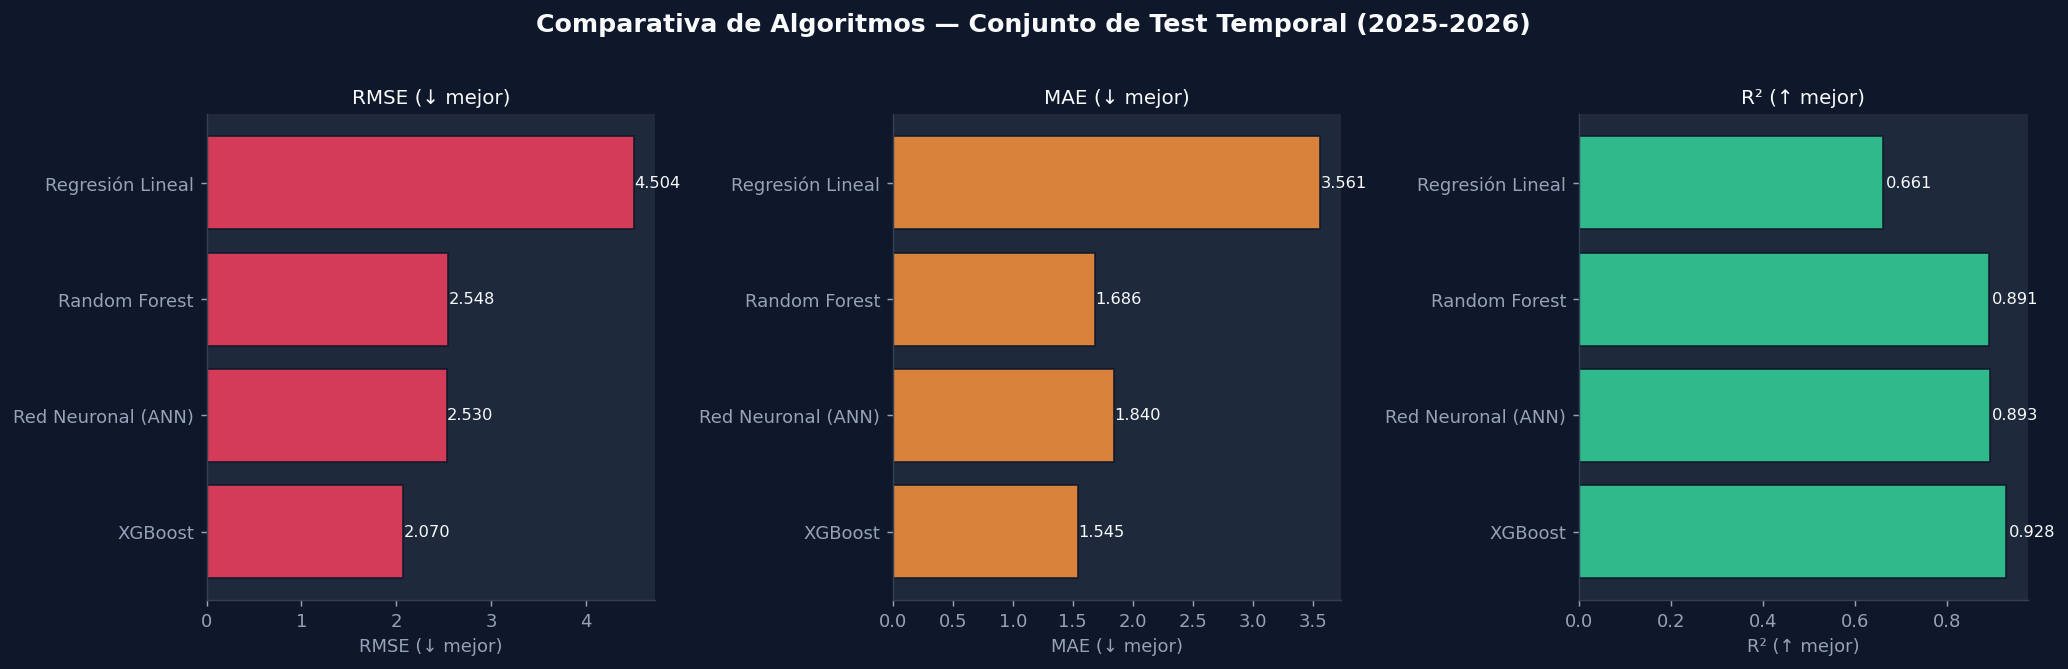

Gráfico guardado en models/comparativa_modelos.png


In [10]:
import os

# Asegurar que el directorio de destino existe
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparativa de Algoritmos — Conjunto de Test Temporal (2025-2026)',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

metrics = [('Test_RMSE', 'RMSE (↓ mejor)', RED),
           ('Test_MAE',  'MAE (↓ mejor)',  ORANGE),
           ('Test_R2',   'R² (↑ mejor)',   GREEN)]

for ax, (col, label, color) in zip(axes, metrics):
    vals   = results_df[col].values
    models = results_df['Modelo'].values
    bars   = ax.barh(models, vals, color=color, alpha=0.85, edgecolor='#0f172a')
    ax.set_xlabel(label, color=MUTED)
    ax.set_title(label, fontsize=11, color=TEXT)
    ax.tick_params(colors=MUTED)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha='left', color=TEXT, fontsize=9)
    ax.set_facecolor(CARD_BG)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
# Se cambia la ruta a una carpeta local válida
save_path = os.path.join(SAVE_DIR, 'comparativa_modelos.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Gráfico guardado en {save_path}')

## 5. Predicción vs. Real — Modelo Champion (XGBoost)

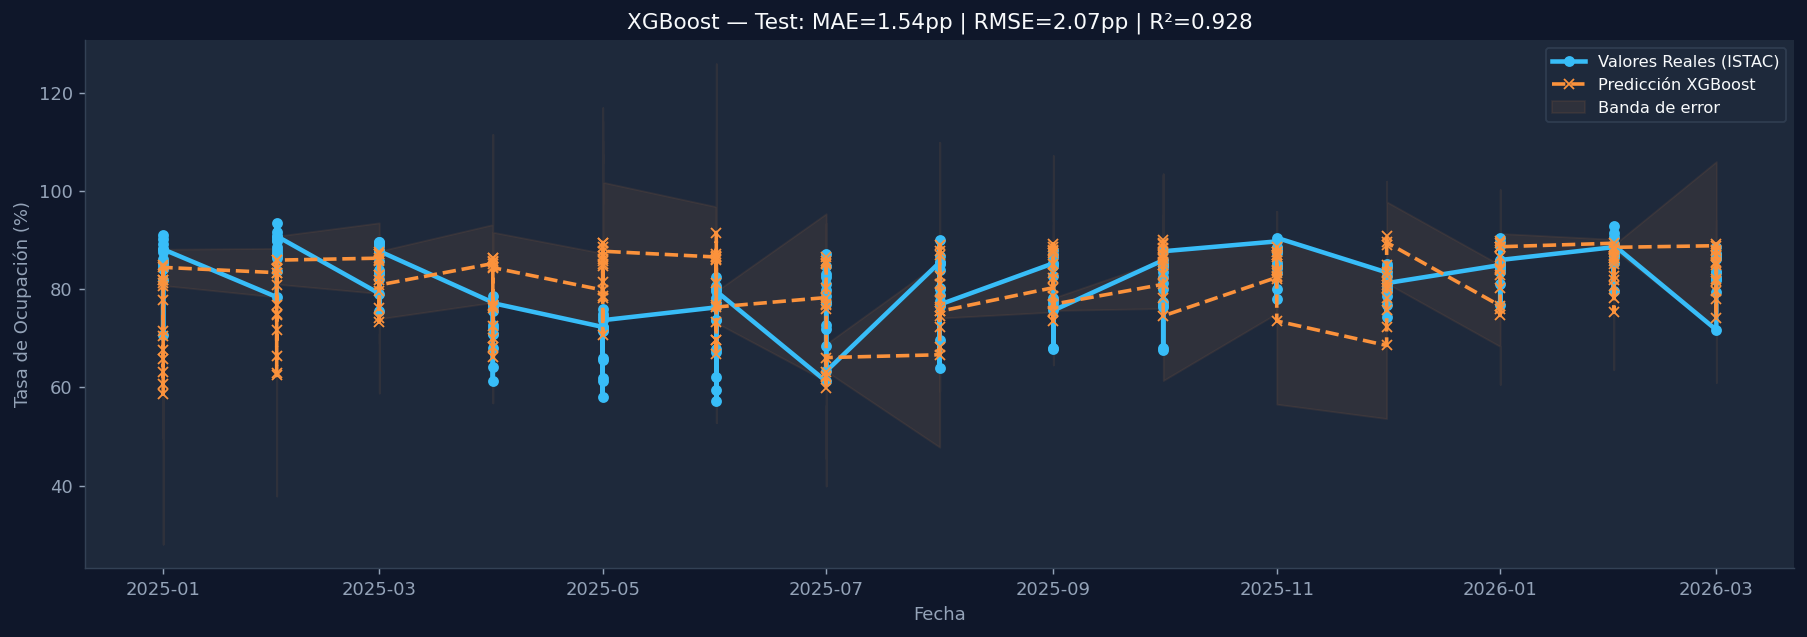

In [11]:
best_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plot_df = test_df[['Date','OBS_VALUE']].copy().sort_values('Date')
plot_df['y_pred'] = y_pred_best

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_df['Date'], plot_df['OBS_VALUE'], color=ACCENT, lw=2.5,
        marker='o', ms=5, label='Valores Reales (ISTAC)')
ax.plot(plot_df['Date'], plot_df['y_pred'], color=ORANGE, lw=2,
        linestyle='--', marker='x', ms=5, label='Predicción XGBoost')

residuals = plot_df['OBS_VALUE'] - plot_df['y_pred']
ax.fill_between(plot_df['Date'],
                plot_df['y_pred'] - residuals.abs(),
                plot_df['y_pred'] + residuals.abs(),
                alpha=0.08, color=ORANGE, label='Banda de error')

ax.set_ylabel('Tasa de Ocupación (%)', color=MUTED)
ax.set_xlabel('Fecha', color=MUTED)
ax.legend(facecolor=CARD_BG, edgecolor='#334155', fontsize=9)
ax.set_facecolor(CARD_BG)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

mae_val  = mean_absolute_error(y_test, y_pred_best)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_val   = r2_score(y_test, y_pred_best)
ax.set_title(f'XGBoost — Test: MAE={mae_val:.2f}pp | RMSE={rmse_val:.2f}pp | R²={r2_val:.3f}',
             fontsize=12, color=TEXT)

plt.tight_layout()
plt.savefig('models/prediccion_vs_real.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 6. Análisis de Residuos

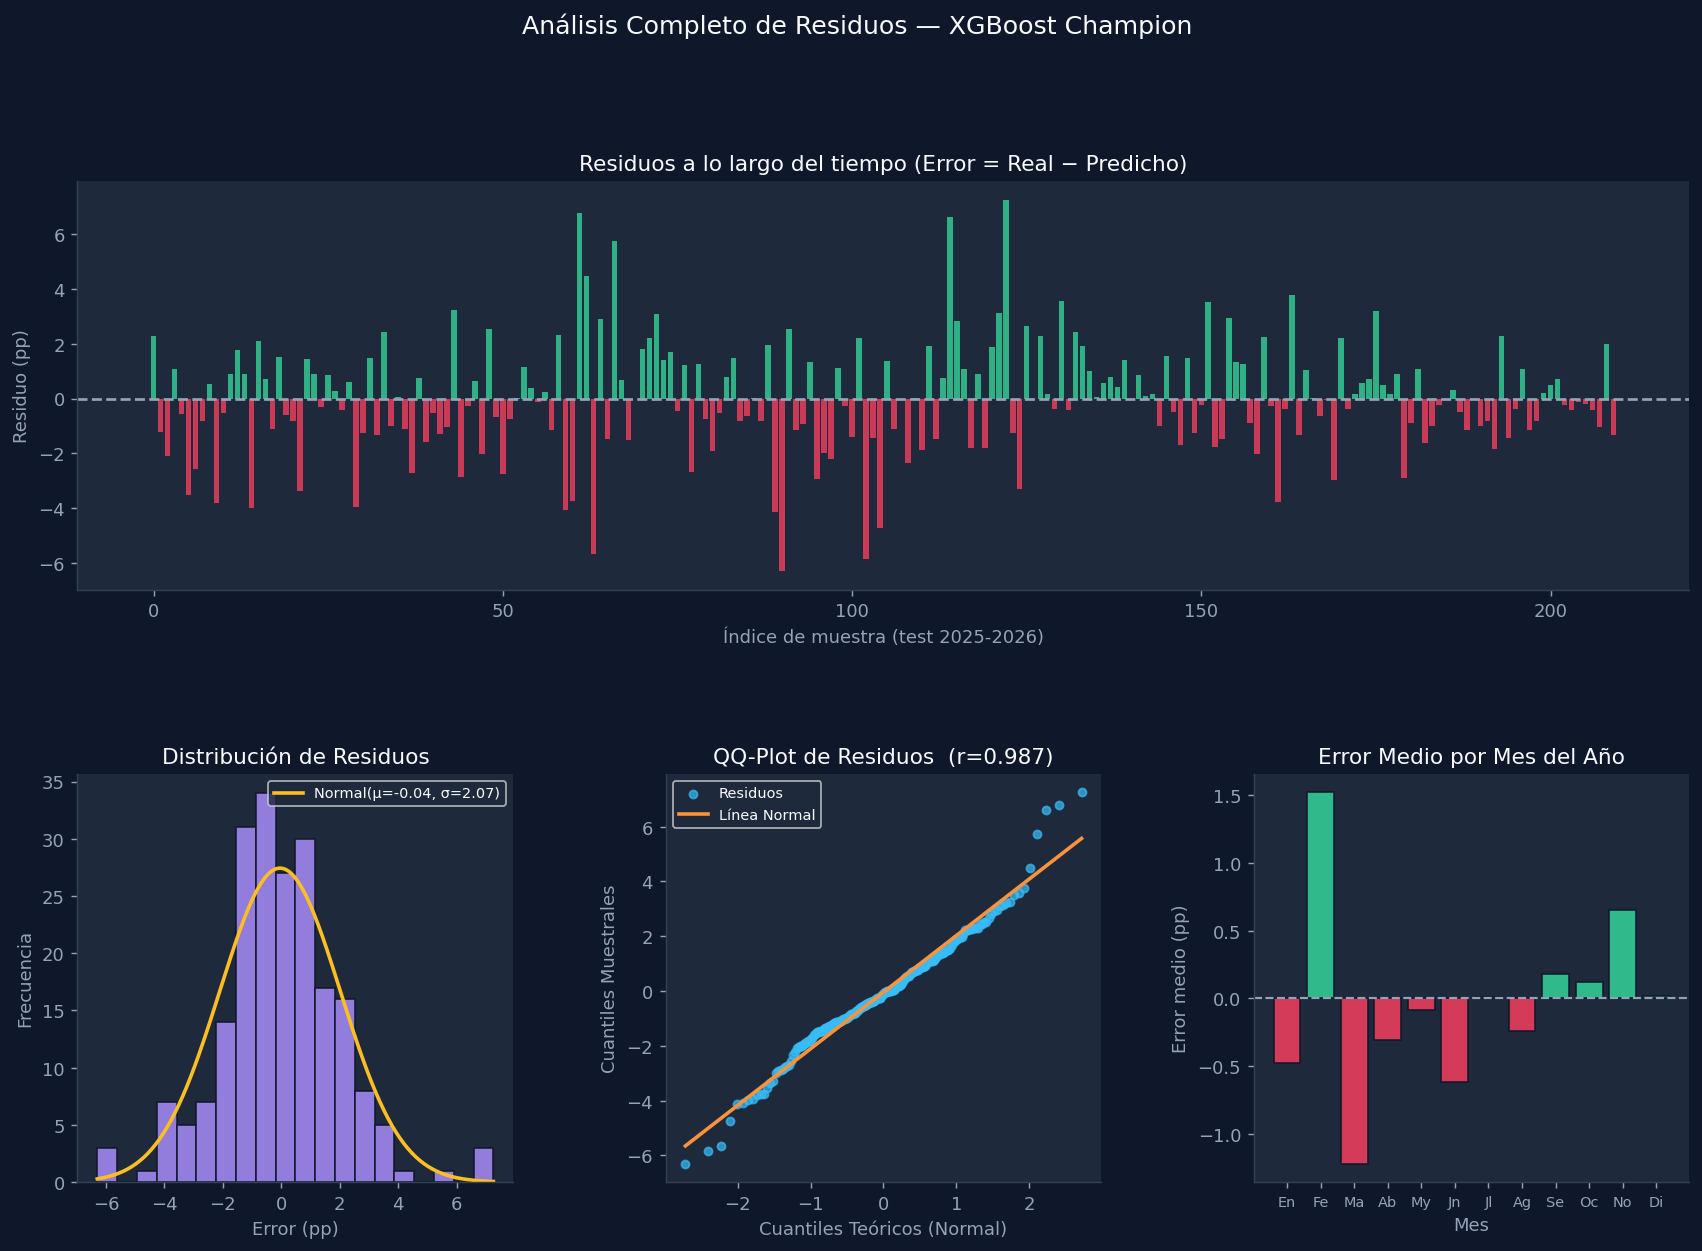

In [12]:
residuals = y_test.values - y_pred_best

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 6.1 Residuos en el tiempo ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(range(len(residuals)), residuals,
        color=[GREEN if r >= 0 else RED for r in residuals], alpha=0.8)
ax1.axhline(0, color=MUTED, lw=1.5, linestyle='--')
ax1.set_title('Residuos a lo largo del tiempo (Error = Real − Predicho)', color=TEXT)
ax1.set_xlabel('Índice de muestra (test 2025-2026)', color=MUTED)
ax1.set_ylabel('Residuo (pp)', color=MUTED)
ax1.set_facecolor(CARD_BG)
for sp in ['top','right']: ax1.spines[sp].set_visible(False)

# ── 6.2 Histograma de residuos ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=20, color=PURPLE, edgecolor=DARK_BG, alpha=0.85)
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 200)
ax2.plot(x, stats.norm.pdf(x, mu, sigma) * len(residuals) * (residuals.max()-residuals.min())/20,
         color=YELLOW, lw=2, label=f'Normal(μ={mu:.2f}, σ={sigma:.2f})')
ax2.set_title('Distribución de Residuos', color=TEXT)
ax2.set_xlabel('Error (pp)', color=MUTED)
ax2.set_ylabel('Frecuencia', color=MUTED)
ax2.legend(facecolor=CARD_BG, fontsize=8)
ax2.set_facecolor(CARD_BG)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

# ── 6.3 QQ-Plot ───────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax3.scatter(osm, osr, color=ACCENT, s=20, alpha=0.7, label='Residuos')
ax3.plot(osm, slope*np.array(osm)+intercept, color=ORANGE, lw=2, label='Línea Normal')
ax3.set_title(f'QQ-Plot de Residuos  (r={r:.3f})', color=TEXT)
ax3.set_xlabel('Cuantiles Teóricos (Normal)', color=MUTED)
ax3.set_ylabel('Cuantiles Muestrales', color=MUTED)
ax3.legend(facecolor=CARD_BG, fontsize=8)
ax3.set_facecolor(CARD_BG)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)

# ── 6.4 Residuos por mes del año (estacionalidad del error) ───────────────────
ax4 = fig.add_subplot(gs[1, 2])
months_test = test_df['Month'].values
month_res   = pd.DataFrame({'Month': months_test, 'Residual': residuals})
month_mean  = month_res.groupby('Month')['Residual'].mean()
colors = [GREEN if v >= 0 else RED for v in month_mean.values]
ax4.bar(month_mean.index, month_mean.values, color=colors, edgecolor=DARK_BG, alpha=0.85)
ax4.axhline(0, color=MUTED, lw=1.2, linestyle='--')
ax4.set_xticks(range(1,13))
ax4.set_xticklabels(['En','Fe','Ma','Ab','My','Jn','Jl','Ag','Se','Oc','No','Di'], fontsize=8)
ax4.set_title('Error Medio por Mes del Año', color=TEXT)
ax4.set_xlabel('Mes', color=MUTED)
ax4.set_ylabel('Error medio (pp)', color=MUTED)
ax4.set_facecolor(CARD_BG)
for sp in ['top','right']: ax4.spines[sp].set_visible(False)

fig.suptitle('Análisis Completo de Residuos — XGBoost Champion', fontsize=14, color=TEXT, y=1.01)
plt.savefig('models/analisis_residuos.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 7. Importancia de Variables (Feature Importance)

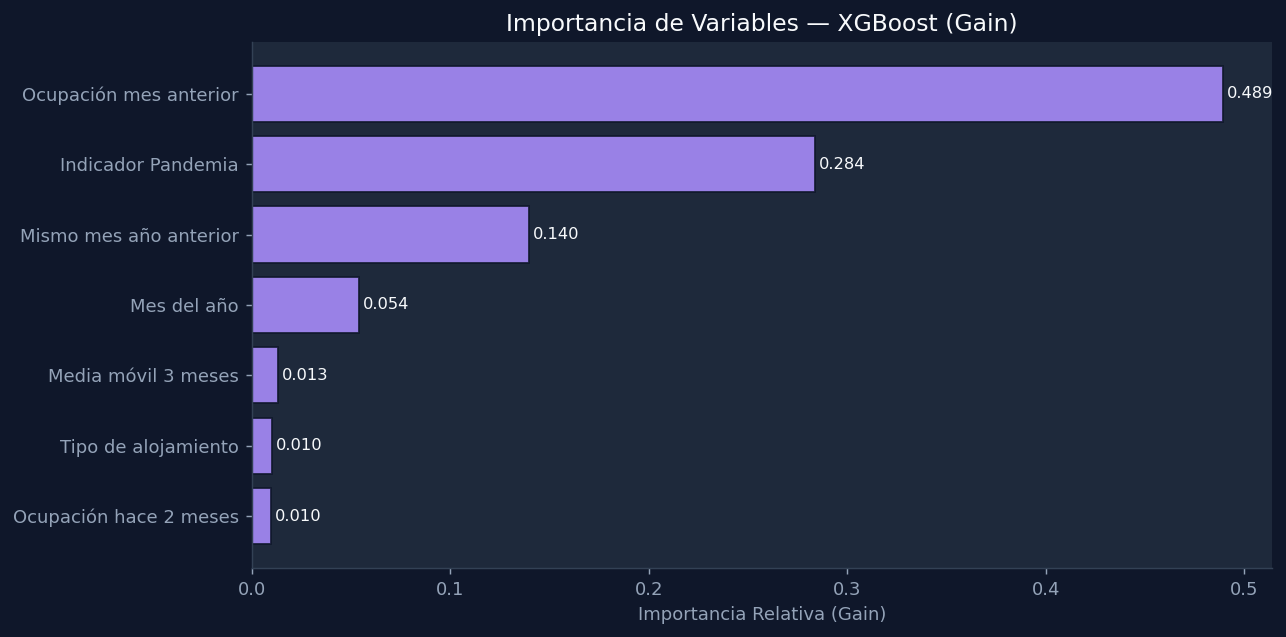


Interpretación:
  Ocupación mes anterior         → 0.489 (48.9%)
  Indicador Pandemia             → 0.284 (28.4%)
  Mismo mes año anterior         → 0.140 (14.0%)
  Mes del año                    → 0.054 (5.4%)
  Media móvil 3 meses            → 0.013 (1.3%)
  Tipo de alojamiento            → 0.010 (1.0%)
  Ocupación hace 2 meses         → 0.010 (1.0%)


In [19]:
importances = best_model.feature_importances_
# Se actualiza la lista para incluir las 7 variables (agregando 'Tipo de alojamiento')
feat_labels = ['Mes del año', 'Ocupación mes anterior', 'Ocupación hace 2 meses',
               'Mismo mes año anterior', 'Media móvil 3 meses', 'Indicador Pandemia',
               'Tipo de alojamiento']
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([feat_labels[i] for i in sorted_idx],
               importances[sorted_idx],
               color=PURPLE, edgecolor=DARK_BG, alpha=0.9)
for bar, v in zip(bars, importances[sorted_idx]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', color=TEXT, fontsize=9)
ax.set_title('Importancia de Variables — XGBoost (Gain)', fontsize=13, color=TEXT)
ax.set_xlabel('Importancia Relativa (Gain)', color=MUTED)
ax.set_facecolor(CARD_BG)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('models/feature_importance.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print('\nInterpretación:')
for i in reversed(sorted_idx):
    print(f'  {feat_labels[i]:<30} → {importances[i]:.3f} ({importances[i]*100:.1f}%)')

## 8. Curva de Aprendizaje (Learning Curve)

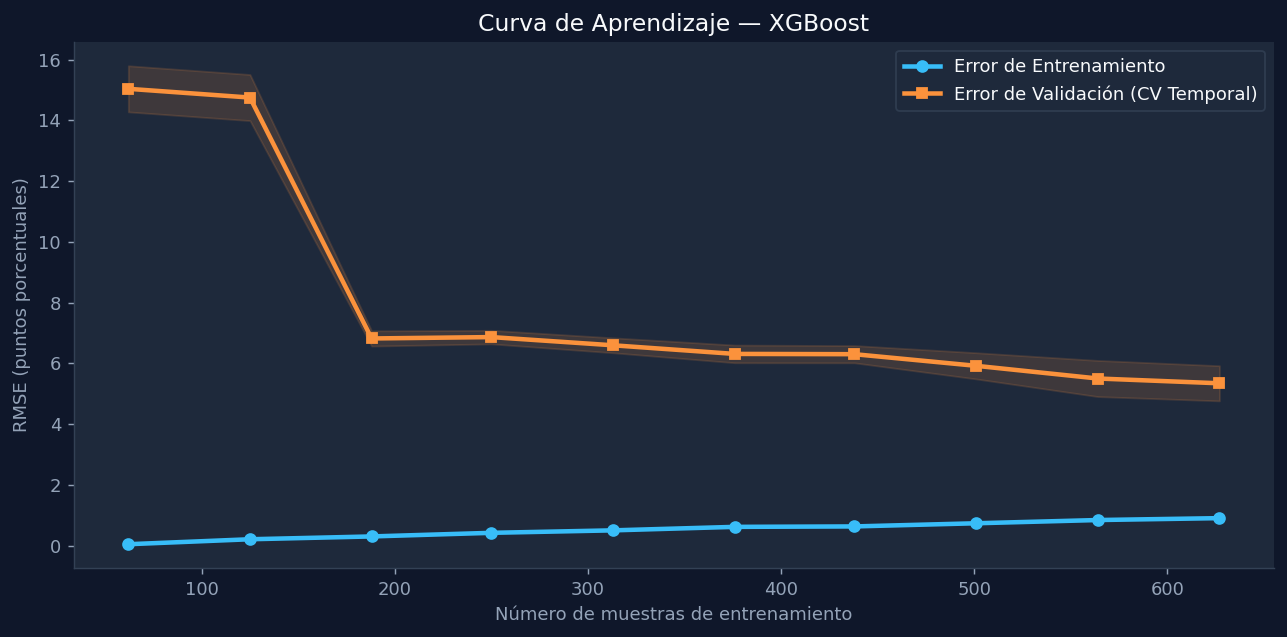

In [14]:
model_lc = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)

train_sizes, train_scores, val_scores = learning_curve(
    model_lc, X_train, y_train,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = -val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, color=ACCENT, lw=2.5, marker='o', label='Error de Entrenamiento')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=ACCENT)
ax.plot(train_sizes, val_mean, color=ORANGE, lw=2.5, marker='s', label='Error de Validación (CV Temporal)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=ORANGE)

ax.set_title('Curva de Aprendizaje — XGBoost', fontsize=13, color=TEXT)
ax.set_xlabel('Número de muestras de entrenamiento', color=MUTED)
ax.set_ylabel('RMSE (puntos porcentuales)', color=MUTED)
ax.legend(facecolor=CARD_BG, edgecolor='#334155')
ax.set_facecolor(CARD_BG)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('models/curva_aprendizaje.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 9. Curva ROC-Like — Clasificación de Temporada Alta/Baja

> **Nota:** XGBoost es un regresor, por lo que la Curva ROC estándar no aplica directamente. Para obtener una métrica equivalente y visualmente potente, se convierte el problema en **clasificación binaria**: predecir si la ocupación será **Alta Temporada (≥ 70%)** o **Baja Temporada (< 70%)**. La probabilidad se aproxima a partir de la predicción numérica normalizada.

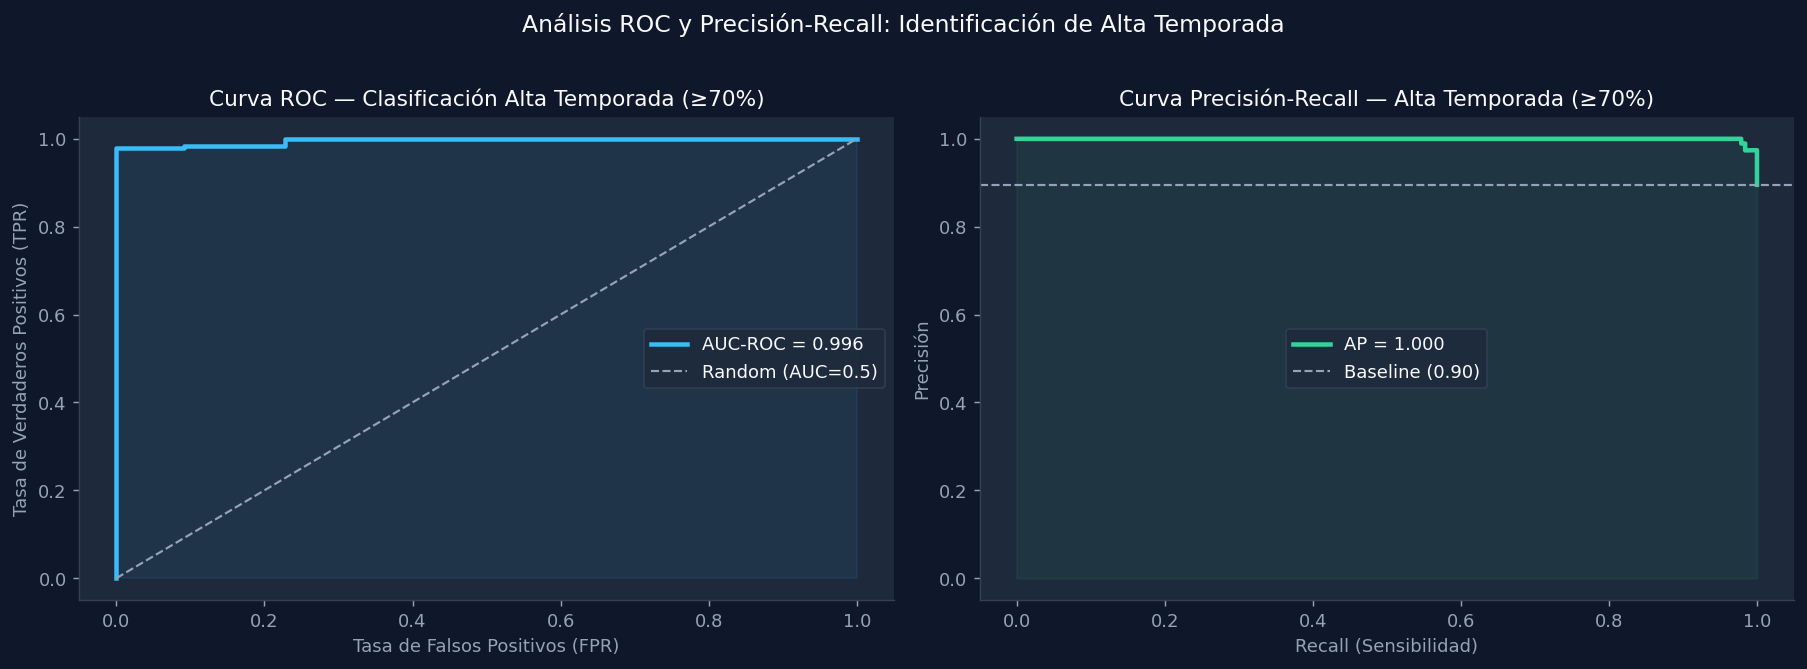

In [15]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import MinMaxScaler

THRESHOLD = 70.0
y_test_bin  = (y_test.values >= THRESHOLD).astype(int)
scaler     = MinMaxScaler()
y_score    = scaler.fit_transform(y_pred_best.reshape(-1,1)).ravel()

fpr, tpr, thresholds = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_bin, y_score)
ap_score = average_precision_score(y_test_bin, y_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fpr, tpr, color=ACCENT, lw=2.5, label=f'AUC-ROC = {roc_auc:.3f}')
ax.plot([0,1], [0,1], color=MUTED, lw=1.2, linestyle='--', label='Random (AUC=0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color=ACCENT)
ax.set_title('Curva ROC — Clasificación Alta Temporada (≥70%)', fontsize=12, color=TEXT)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', color=MUTED)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', color=MUTED)
ax.legend(facecolor=CARD_BG, edgecolor='#334155')
ax.set_facecolor(CARD_BG)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

ax2 = axes[1]
ax2.plot(recall, precision, color=GREEN, lw=2.5, label=f'AP = {ap_score:.3f}')
baseline = y_test_bin.sum() / len(y_test_bin)
ax2.axhline(baseline, color=MUTED, lw=1.2, linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.fill_between(recall, precision, alpha=0.08, color=GREEN)
ax2.set_title('Curva Precisión-Recall — Alta Temporada (≥70%)', fontsize=12, color=TEXT)
ax2.set_xlabel('Recall (Sensibilidad)', color=MUTED)
ax2.set_ylabel('Precisión', color=MUTED)
ax2.legend(facecolor=CARD_BG, edgecolor='#334155')
ax2.set_facecolor(CARD_BG)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

plt.suptitle('Análisis ROC y Precisión-Recall: Identificación de Alta Temporada',
             fontsize=13, color=TEXT, y=1.02)
plt.tight_layout()
plt.savefig('models/curva_roc.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 10. Estabilidad del Modelo — Varianza de Predicciones por Fold (CV)

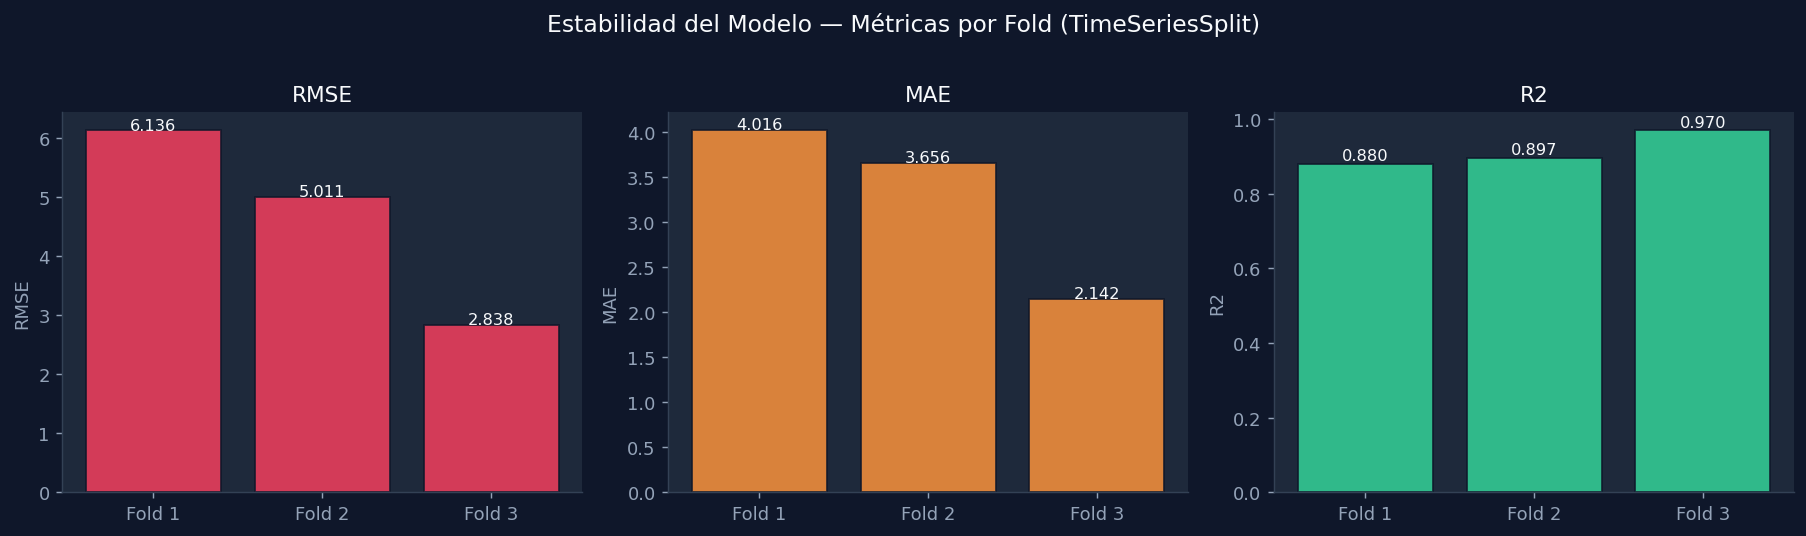

In [16]:
fold_metrics = []
for fold_i, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    m = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    p = m.predict(X_train.iloc[val_idx])
    fold_metrics.append({
        'Fold': f'Fold {fold_i}',
        'RMSE': np.sqrt(mean_squared_error(y_train.iloc[val_idx], p)),
        'MAE':  mean_absolute_error(y_train.iloc[val_idx], p),
        'R2':   r2_score(y_train.iloc[val_idx], p)
    })

fm_df = pd.DataFrame(fold_metrics)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['RMSE','MAE','R2'], [RED, ORANGE, GREEN]):
    bars = ax.bar(fm_df['Fold'], fm_df[col], color=color, edgecolor=DARK_BG, alpha=0.85)
    for bar, v in zip(bars, fm_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', color=TEXT, fontsize=9)
    ax.set_title(col, color=TEXT)
    ax.set_ylabel(col, color=MUTED)
    ax.set_facecolor(CARD_BG)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('Estabilidad del Modelo — Métricas por Fold (TimeSeriesSplit)',
             fontsize=13, color=TEXT, y=1.02)
plt.tight_layout()
plt.savefig('models/estabilidad_folds.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 11. Análisis de Errores por Categoría de Hotel

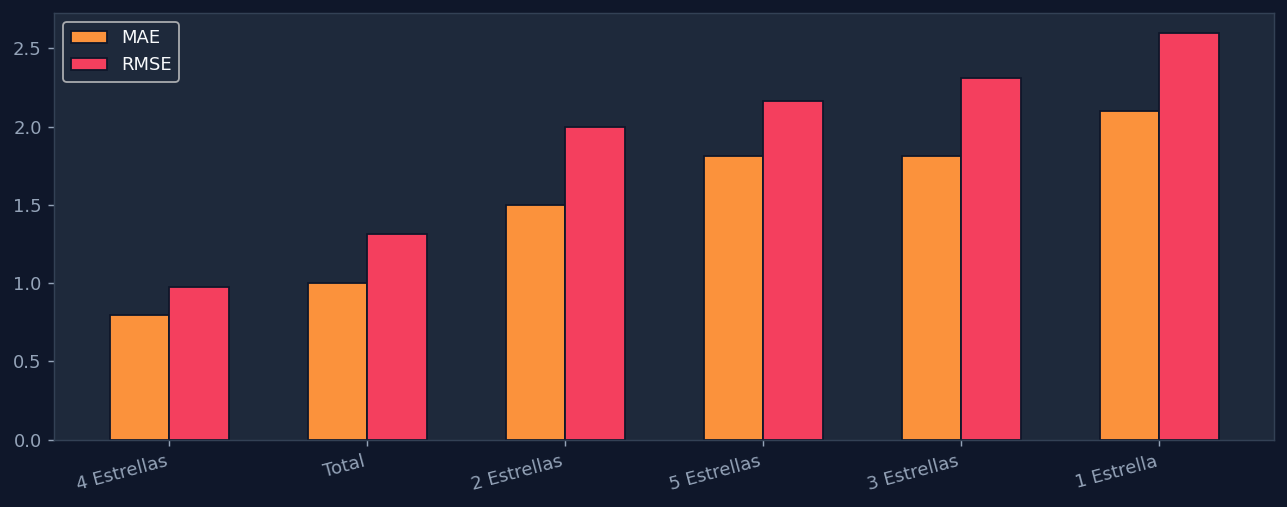

In [17]:
cat_labels = {'_T': 'Total', 'ESTRELLAS_5': '5 Estrellas', 'ESTRELLAS_4': '4 Estrellas', 'ESTRELLAS_3': '3 Estrellas', 'ESTRELLAS_2': '2 Estrellas', 'ESTRELLAS_1': '1 Estrella'}
cat_results = []
for cat, label in cat_labels.items():
    test_cat = test_df[test_df['ALOJAMIENTO_TURISTICO_CATEGORIA_CODE'] == cat]
    if len(test_cat) < 3: continue
    y_cat_pred = best_model.predict(test_cat[FEATURES])
    cat_results.append({'Categoría': label, 'MAE': mean_absolute_error(test_cat[TARGET], y_cat_pred), 'RMSE': np.sqrt(mean_squared_error(test_cat[TARGET], y_cat_pred))})

cat_df = pd.DataFrame(cat_results).sort_values('RMSE')
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(cat_df))
w = 0.3
ax.bar(x - w/2, cat_df['MAE'], w, color=ORANGE, label='MAE', edgecolor=DARK_BG)
ax.bar(x + w/2, cat_df['RMSE'], w, color=RED, label='RMSE', edgecolor=DARK_BG)
ax.set_xticks(x)
ax.set_xticklabels(cat_df['Categoría'], rotation=15, ha='right')
ax.legend(facecolor=CARD_BG)
ax.set_facecolor(CARD_BG)
plt.tight_layout()
plt.savefig('models/error_por_categoria.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

## 12. Resumen Final de Métricas

In [20]:
print('=' * 62)
print('   RESUMEN COMPLETO DE MÉTRICAS — XGBOOST CHAMPION')
print('=' * 62)
print(f"  MAE  (Error Absoluto Medio)      : {mae_val:.3f} pp")
print(f"  RMSE (Raíz Error Cuadrático Med.): {rmse_val:.3f} pp")
print(f"  R²   (Coef. Determinación)       : {r2_val:.3f}  ({r2_val*100:.1f}% varianza explicada)")
print(f"  MAPE (Error Porcentual Absoluto)  : {mean_absolute_percentage_error(y_test, y_pred_best)*100:.2f}%")
print(f"  AUC-ROC (Alt. Temporada ≥70%)    : {roc_auc:.3f}")
print(f"  AP   (Average Precision)         : {ap_score:.3f}")
print('=' * 62)

print('\nArchivos de diagnóstico generados en models/:')
for fname in ['comparativa_modelos.png','prediccion_vs_real.png', 'analisis_residuos.png','curva_aprendizaje.png', 'curva_roc.png','estabilidad_folds.png','feature_importance.png', 'error_por_categoria.png']:
    path = os.path.join('models', fname)
    exists = '✅' if os.path.exists(path) else '☐ no encontrado'
    print(f'  {exists}  {fname}')

   RESUMEN COMPLETO DE MÉTRICAS — XGBOOST CHAMPION
  MAE  (Error Absoluto Medio)      : 1.545 pp
  RMSE (Raíz Error Cuadrático Med.): 2.070 pp
  R²   (Coef. Determinación)       : 0.928  (92.8% varianza explicada)
  MAPE (Error Porcentual Absoluto)  : 1.94%
  AUC-ROC (Alt. Temporada ≥70%)    : 0.996
  AP   (Average Precision)         : 1.000

Archivos de diagnóstico generados en models/:
  ✅  comparativa_modelos.png
  ✅  prediccion_vs_real.png
  ✅  analisis_residuos.png
  ✅  curva_aprendizaje.png
  ✅  curva_roc.png
  ✅  estabilidad_folds.png
  ✅  feature_importance.png
  ✅  error_por_categoria.png
